# Helper Functions

In [ ]:
import numpy as np
import os
from nilearn import datasets

def filter_task_data(X, y_group, y_task, groups, task_id):
    """Returns only the data and labels associated with a specific task_id."""
    mask = (y_task == task_id)
    return X[mask], y_group[mask], groups[mask]

def average_by_subject(X_subset, y_subset, groups_subset):
    """Averages multiple runs/trials for each unique subject."""
    X_avg, y_avg = [], []
    unique_subs = np.unique(groups_subset)
    
    for sub in unique_subs:
        sub_indices = np.where(groups_subset == sub)[0]
        # Mean across features for this participant
        X_avg.append(np.mean(X_subset[sub_indices], axis=0))
        # Keep the label (TD or MLD)
        y_avg.append(y_subset[sub_indices[0]])
        
    return np.array(X_avg), np.array(y_avg)

X = np.load('data/X_features.npy')
y_groups = np.load('data/y_labels.npy')
y_task = np.load('data/y_tasks.npy')
groups = np.load('data/subject_groups.npy')

def get_all_data():
    X_avg, y_avg = average_by_subject(X, y_groups, groups)
    return X_avg, y_avg

def get_mult_data():
    X_m, y_m, g_m = filter_task_data(X, y_groups, y_task, groups, task_id=1)
    X_avg_m, y_avg_m = average_by_subject(X_m, y_m, g_m)
    return X_avg_m, y_avg_m

def get_sub_data():
    X_s, y_s, g_s = filter_task_data(X, y_groups, y_task, groups, task_id=0)
    X_avg_s, y_avg_s = average_by_subject(X_s, y_s, g_s)
    return X_avg_s, y_avg_s

def get_labels():
    atlas = datasets.fetch_atlas_schaefer_2018(n_rois=100, yeo_networks=7)
    labels = atlas.labels
    return labels

# Support Vector Machine SVM

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
# Removed SelectKBest imports since we aren't using them
from helper_lin import get_all_data, get_mult_data, get_sub_data, get_labels 

labels = get_labels()

def svm_show_results_skf(X_avg, y_avg, task_name):
    # 1. Define Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        # Re-added probability=True so predict_proba() works in the loop
        ('svm', SVC(kernel='linear', C=1.0, probability=True, random_state=42)) 
    ])
    
    # 2. Stratified K Fold Cross-Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    
    for train_idx, test_idx in skf.split(X_avg, y_avg):
        # Fit on training fold
        pipeline.fit(X_avg[train_idx], y_avg[train_idx])
        
        # Predict on testing fold
        predictions = pipeline.predict(X_avg[test_idx])
        probs = pipeline.predict_proba(X_avg[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y_avg[test_idx])
        y_probs_all.extend(probs)
    
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)

    # 3. Calculate and Print Metrics
    acc = accuracy_score(y_test_all, y_pred_all)
    
    print(f"\n{'='*120}")
    print(f"{task_name} (Averaged) Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))

    # 4. Plotting Confusion Matrix
    plt.figure(figsize=(5, 4))
    # FIX: Use y_test_all here, NOT y_avg, so the shuffled indices match
    cm = confusion_matrix(y_test_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Pred TD', 'Pred MLD'], yticklabels=['Actual TD', 'Actual MLD'])
    plt.title(f"{task_name} Confusion Matrix")
    plt.show()

    # 5. Feature Importance (Weights)
    # Fit on the WHOLE dataset to get the final, stable model weights
    pipeline.fit(X_avg, y_avg)
    
    # FIX: Since SelectKBest is gone, we just grab all the weights directly from the SVM.
    weights = pipeline.named_steps['svm'].coef_[0]
    
    # Map to ROI pairs (Schaefer 100 uses upper triangle indices)
    roi_indices = np.triu_indices(100, k=1)
    roi_pairs = list(zip(roi_indices[0], roi_indices[1]))

    print(f"\nTop 10 Strongest Connections for {task_name}:")
    print(f"{'Brain Connection':<55} | {'Weight':<10}")
    print("-" * 70)

    # Sort by absolute weight value (largest to smallest)
    sorted_idx = np.argsort(np.abs(weights))[::-1]

    # Print the top 10 most influential brain connections
    for i in range(10):
        feat_idx = sorted_idx[i]
        roi_a, roi_b = roi_pairs[feat_idx]
        
        name_a = labels[roi_a] 
        name_b = labels[roi_b]
        
        # Clean labels and print
        connection_str = f"{name_a} <-> {name_b}"
        # Print the actual weight (with its positive/negative sign)
        print(f"{connection_str:<55} | {weights[feat_idx]:.4f}") 
    
    return y_test_all, y_pred_all, y_probs_all

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018



All (Averaged) Accuracy: 63.33%
              precision    recall  f1-score   support

          TD       0.64      0.60      0.62        15
         MLD       0.62      0.67      0.65        15

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.63        30
weighted avg       0.63      0.63      0.63        30



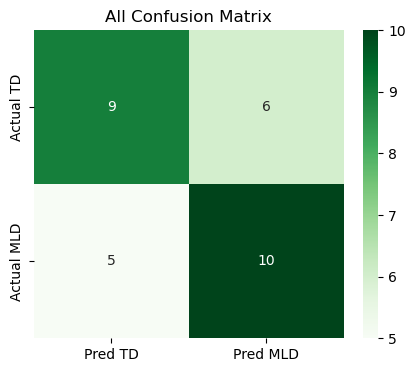


Top 10 Strongest Connections for All:
Brain Connection                                        | Weight    
----------------------------------------------------------------------
7Networks_LH_Vis_8 <-> 7Networks_RH_SomMot_2 | -0.0077
7Networks_RH_Vis_8 <-> 7Networks_RH_DorsAttn_Post_1 | -0.0066
7Networks_LH_Cont_Cing_1 <-> 7Networks_LH_Default_PFC_4 | 0.0062
7Networks_RH_Vis_8 <-> 7Networks_RH_DorsAttn_Post_5 | -0.0060
7Networks_RH_SomMot_1 <-> 7Networks_RH_Cont_Cing_1 | -0.0057
7Networks_LH_DorsAttn_Post_2 <-> 7Networks_LH_SalVentAttn_Med_1 | 0.0057
7Networks_RH_SomMot_1 <-> 7Networks_RH_Limbic_OFC_1 | -0.0056
7Networks_RH_Vis_2 <-> 7Networks_RH_SalVentAttn_FrOperIns_1 | 0.0055
7Networks_RH_SomMot_1 <-> 7Networks_RH_Limbic_TempPole_1 | -0.0055
7Networks_LH_DorsAttn_PrCv_1 <-> 7Networks_RH_Default_Temp_1 | 0.0055


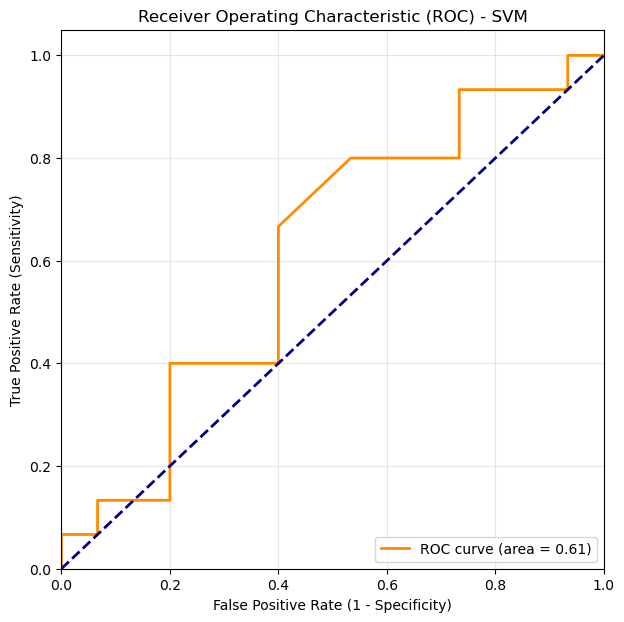

In [24]:
X_avg, y_avg = get_all_data()
y_true, y_pred, y_probs = svm_show_results_skf(X_avg, y_avg, "All")
plt_roc_curve(y_true, y_probs[:, 1], model_name="SVM")

# Multi Layer Perceptron MLP

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from helper_lin import get_all_data, get_mult_data, get_sub_data, get_labels 

labels = get_labels()

def mlp_show_results_skf(X_avg, y_avg, task_name):
    # 1. Define Literature-Backed Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=(64, 16), # Funnel architecture for dimensionality reduction
            activation='relu',            
            solver='adam',                
            alpha=0.05,                   # Strong L2 regularization (Weight Decay)
            early_stopping=True,          
            validation_fraction=0.1,      
            max_iter=1000,                
            random_state=42
        )) 
    ])
    
    # 2. Stratified K Fold Cross-Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    
    for train_idx, test_idx in skf.split(X_avg, y_avg):
        pipeline.fit(X_avg[train_idx], y_avg[train_idx])
        
        predictions = pipeline.predict(X_avg[test_idx])
        probs = pipeline.predict_proba(X_avg[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y_avg[test_idx])
        y_probs_all.extend(probs)
    
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)

    # 3. Calculate and Print Metrics
    acc = accuracy_score(y_test_all, y_pred_all)
    
    print(f"\n{'='*120}")
    print(f"{task_name} (MLP Averaged) Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))

    # 4. Plotting Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', # Changed to Blues to differentiate from the SVM's Greens
                xticklabels=['Pred TD', 'Pred MLD'], yticklabels=['Actual TD', 'Actual MLD'])
    plt.title(f"{task_name} MLP Confusion Matrix")
    plt.show()

    # 5. Feature Importance (Heuristic for MLP)
    pipeline.fit(X_avg, y_avg)
    
    # Extract weights from the Input Layer to the First Hidden Layer
    # Shape of coefs_[0] is (n_features, n_hidden_layer_1)
    W1 = pipeline.named_steps['mlp'].coefs_[0]
    
    # Heuristic: Sum the absolute values of the weights for each input feature 
    # across all neurons in the first hidden layer.
    feature_importances = np.sum(np.abs(W1), axis=1)
    
    # Map to ROI pairs
    roi_indices = np.triu_indices(100, k=1)
    roi_pairs = list(zip(roi_indices[0], roi_indices[1]))

    print(f"\nTop 10 Most Influential Connections for {task_name} (MLP W1-Norm Heuristic):")
    print(f"{'Brain Connection':<55} | {'Importance':<10}")
    print("-" * 70)

    # Sort by calculated importance value (largest to smallest)
    sorted_idx = np.argsort(feature_importances)[::-1]

    for i in range(10):
        feat_idx = sorted_idx[i]
        roi_a, roi_b = roi_pairs[feat_idx]
        
        name_a = labels[roi_a] 
        name_b = labels[roi_b]
        
        connection_str = f"{name_a} <-> {name_b}"
        print(f"{connection_str:<55} | {feature_importances[feat_idx]:.4f}") 
    
    return y_test_all, y_pred_all, y_probs_all

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018



All (MLP Averaged) Accuracy: 63.33%
              precision    recall  f1-score   support

          TD       0.64      0.60      0.62        15
         MLD       0.62      0.67      0.65        15

    accuracy                           0.63        30
   macro avg       0.63      0.63      0.63        30
weighted avg       0.63      0.63      0.63        30



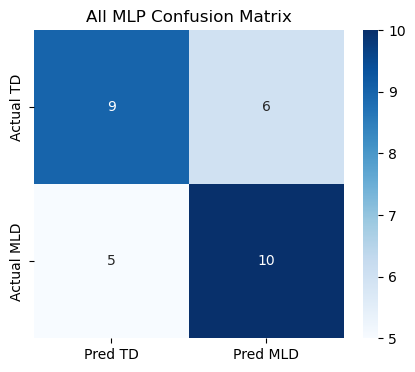


Top 10 Most Influential Connections for All (MLP W1-Norm Heuristic):
Brain Connection                                        | Importance
----------------------------------------------------------------------
7Networks_LH_Default_Par_1 <-> 7Networks_RH_Vis_8       | 1.3979
7Networks_LH_Default_Par_1 <-> 7Networks_RH_Vis_6       | 1.3687
7Networks_LH_Vis_9 <-> 7Networks_LH_Default_PFC_3       | 1.3544
7Networks_LH_Default_PFC_6 <-> 7Networks_RH_DorsAttn_FEF_1 | 1.3493
7Networks_LH_SomMot_5 <-> 7Networks_RH_SalVentAttn_Med_2 | 1.3443
7Networks_LH_SalVentAttn_ParOper_1 <-> 7Networks_LH_Default_PFC_6 | 1.3417
7Networks_RH_Vis_3 <-> 7Networks_RH_SomMot_5            | 1.3356
7Networks_RH_Default_PFCv_2 <-> 7Networks_RH_Default_pCunPCC_1 | 1.3340
7Networks_LH_Default_Par_1 <-> 7Networks_RH_Cont_PFCl_3 | 1.3328
7Networks_RH_SomMot_1 <-> 7Networks_RH_SomMot_6         | 1.3325


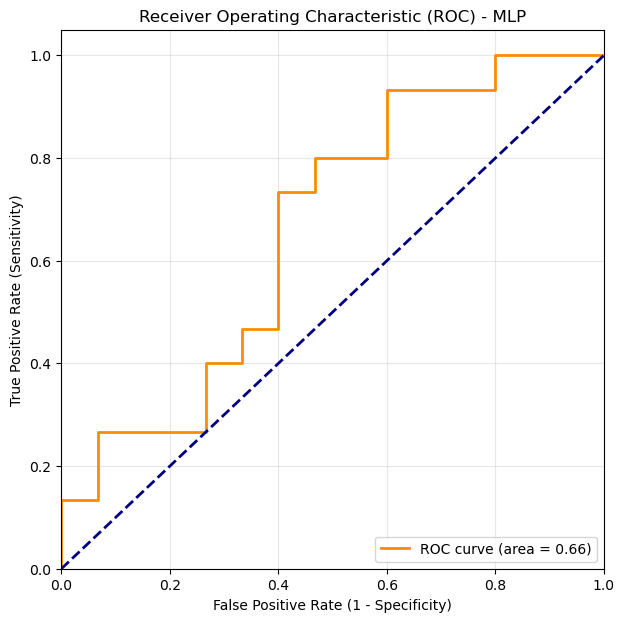

In [26]:
X_avg, y_avg = get_all_data()
y_true, y_pred, y_probs = mlp_show_results_skf(X_avg, y_avg,"All")
plt_roc_curve(y_true, y_probs[:, 1], model_name="MLP")

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from helper_lin import get_all_data, get_mult_data, get_sub_data, get_labels 

labels = get_labels()

def xgb_show_results_skf(X_avg, y_avg, task_name):
    # 1. Define Literature-Backed Pipeline
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('xgb', XGBClassifier(
            max_depth=3,              
            learning_rate=0.05,       
            n_estimators=100,         
            subsample=0.8,            
            colsample_bytree=0.1,     
            reg_alpha=1.0,            
            reg_lambda=1.0,           
            eval_metric='logloss',
            random_state=42
        )) 
    ])
    
    # 2. Stratified K Fold Cross-Validation
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    y_pred_all = []
    y_test_all = []
    y_probs_all = []
    
    for train_idx, test_idx in skf.split(X_avg, y_avg):
        pipeline.fit(X_avg[train_idx], y_avg[train_idx])
        
        predictions = pipeline.predict(X_avg[test_idx])
        probs = pipeline.predict_proba(X_avg[test_idx])
        
        y_pred_all.extend(predictions)
        y_test_all.extend(y_avg[test_idx])
        y_probs_all.extend(probs)
    
    y_pred_all = np.array(y_pred_all)
    y_test_all = np.array(y_test_all)
    y_probs_all = np.array(y_probs_all)

    # 3. Calculate and Print Metrics
    acc = accuracy_score(y_test_all, y_pred_all)
    
    print(f"\n{'='*120}")
    print(f"{task_name} (XGBoost Averaged) Accuracy: {acc * 100:.2f}%")
    print(classification_report(y_test_all, y_pred_all, target_names=['TD', 'MLD']))

    # 4. Plotting Confusion Matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test_all, y_pred_all)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', # Orange to visually separate from SVM and MLP
                xticklabels=['Pred TD', 'Pred MLD'], yticklabels=['Actual TD', 'Actual MLD'])
    plt.title(f"{task_name} XGBoost Confusion Matrix")
    plt.show()

    # 5. Feature Importance (Native to XGBoost)
    pipeline.fit(X_avg, y_avg)
    
    # XGBoost natively calculates the importance of each feature
    feature_importances = pipeline.named_steps['xgb'].feature_importances_
    
    # Map to ROI pairs
    roi_indices = np.triu_indices(100, k=1)
    roi_pairs = list(zip(roi_indices[0], roi_indices[1]))

    print(f"\nTop 10 Most Influential Connections for {task_name} (XGBoost Native Importance):")
    print(f"{'Brain Connection':<55} | {'Importance':<10}")
    print("-" * 70)

    # Sort by calculated importance value (largest to smallest)
    sorted_idx = np.argsort(feature_importances)[::-1]

    for i in range(10):
        feat_idx = sorted_idx[i]
        roi_a, roi_b = roi_pairs[feat_idx]
        
        name_a = labels[roi_a] 
        name_b = labels[roi_b]
        
        connection_str = f"{name_a} <-> {name_b}"
        print(f"{connection_str:<55} | {feature_importances[feat_idx]:.4f}") 
    
    return y_test_all, y_pred_all, y_probs_all

[fetch_atlas_schaefer_2018] Dataset found in /Users/jchong058/nilearn_data/schaefer_2018



All (XGBoost Averaged) Accuracy: 56.67%
              precision    recall  f1-score   support

          TD       0.56      0.60      0.58        15
         MLD       0.57      0.53      0.55        15

    accuracy                           0.57        30
   macro avg       0.57      0.57      0.57        30
weighted avg       0.57      0.57      0.57        30



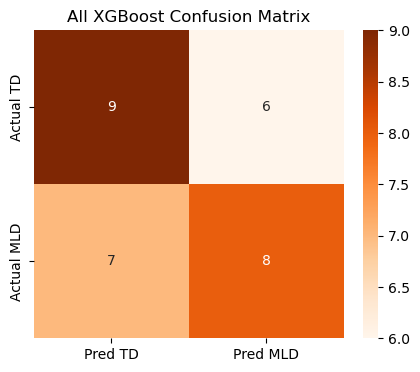


Top 10 Most Influential Connections for All (XGBoost Native Importance):
Brain Connection                                        | Importance
----------------------------------------------------------------------
7Networks_LH_Limbic_OFC_1 <-> 7Networks_RH_Vis_8        | 0.0324
7Networks_LH_DorsAttn_Post_6 <-> 7Networks_RH_Vis_4     | 0.0315
7Networks_LH_Limbic_OFC_1 <-> 7Networks_RH_Vis_3        | 0.0276
7Networks_LH_DorsAttn_Post_2 <-> 7Networks_RH_Cont_PFCl_2 | 0.0275
7Networks_LH_SalVentAttn_PFCl_1 <-> 7Networks_RH_DorsAttn_Post_5 | 0.0263
7Networks_LH_SalVentAttn_Med_3 <-> 7Networks_RH_DorsAttn_Post_5 | 0.0216
7Networks_LH_Vis_3 <-> 7Networks_LH_SalVentAttn_PFCl_1  | 0.0205
7Networks_LH_DorsAttn_Post_6 <-> 7Networks_RH_SomMot_4  | 0.0200
7Networks_LH_Cont_pCun_1 <-> 7Networks_RH_Vis_4         | 0.0196
7Networks_LH_DorsAttn_Post_2 <-> 7Networks_RH_Vis_1     | 0.0194


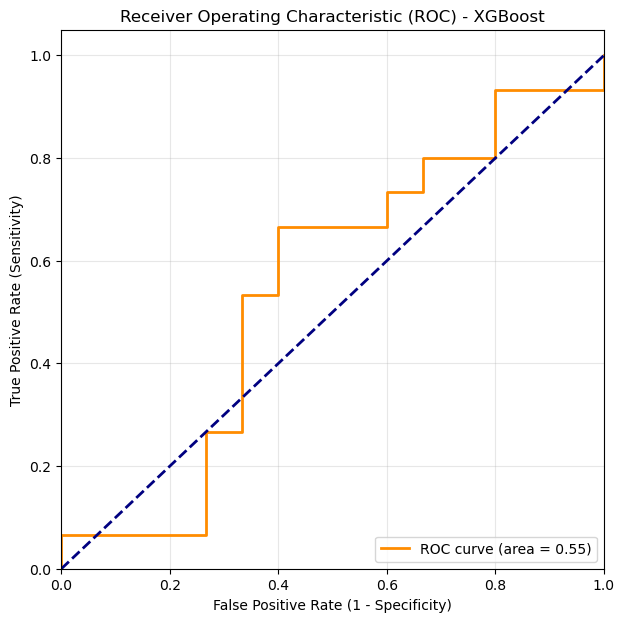

In [28]:
X_avg, y_avg = get_all_data()
y_true, y_pred, y_probs = xgb_show_results_skf(X_avg, y_avg,"All")
plt_roc_curve(y_true, y_probs[:, 1], model_name="XGBoost")